In [6]:
# Standard imports
import sys
from pathlib import Path

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

# Project modules
from src.data.preprocess import load_and_clean_data
from src.features.build_features import engineer_features

# Load data, labels, and clusters
data, labels = load_and_clean_data()
data_eng = engineer_features(data)
pipeline = joblib.load("models/preprocessing_pipeline.pkl")
kmeans_model = joblib.load("models/champion_kmeans.pkl")

X = pipeline.transform(data_eng)
clusters = kmeans_model.predict(X)

# Combine everything
df_analysis = data_eng.copy()
df_analysis['cluster'] = clusters
df_analysis = pd.concat([df_analysis, labels.reset_index(drop=True)], axis=1)

print("Cluster Distribution:")
print(df_analysis['cluster'].value_counts().sort_index())

# Failure rate per cluster
failure_rate = df_analysis.groupby('cluster')['Machine failure'].mean()
print("\nFailure Rate by Cluster:")
print(failure_rate.round(4))

# Failure mode breakdown per cluster
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
for mode in failure_modes:
    print(f"\n{mode} rate by cluster:")
    print(df_analysis.groupby('cluster')[mode].mean().round(4))

INFO:root:Resolved full path: C:\ws-python\predictive-maintenance-clustering\data\raw\ai4i2020.csv
INFO:root:Loaded dataset with shape: (10000, 14)
INFO:root:Features shape: (10000, 6) | Labels shape: (10000, 6)


Cluster Distribution:
cluster
0    3542
1    1722
2    2369
3    2367
Name: count, dtype: int64

Failure Rate by Cluster:
cluster
0    0.0203
1    0.0238
2    0.0380
3    0.0575
Name: Machine failure, dtype: float64

TWF rate by cluster:
cluster
0    0.0034
1    0.0041
2    0.0000
3    0.0114
Name: TWF, dtype: float64

HDF rate by cluster:
cluster
0    0.0003
1    0.0000
2    0.0291
3    0.0190
Name: HDF, dtype: float64

PWF rate by cluster:
cluster
0    0.0085
1    0.0180
2    0.0084
3    0.0059
Name: PWF, dtype: float64

OSF rate by cluster:
cluster
0    0.0096
1    0.0000
2    0.0000
3    0.0270
Name: OSF, dtype: float64

RNF rate by cluster:
cluster
0    0.0011
1    0.0006
2    0.0025
3    0.0034
Name: RNF, dtype: float64


Scaled Cluster Centroids:


,num__Air temperature [K],num__Process temperature [K],num__Rotational speed [rpm],num__Torque [Nm],num__Tool wear [min],cat__Type_L,cat__Type_M
0,-1.300,-0.601,-0.031,-0.004,-0.021,0.000,-0.004
1,1.473,-1.570,-0.058,0.011,0.086,-0.073,0.003
2,0.400,1.122,-0.869,-0.009,0.001,0.019,0.003
3,0.471,0.919,0.958,0.007,-0.033,0.034,0.000


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


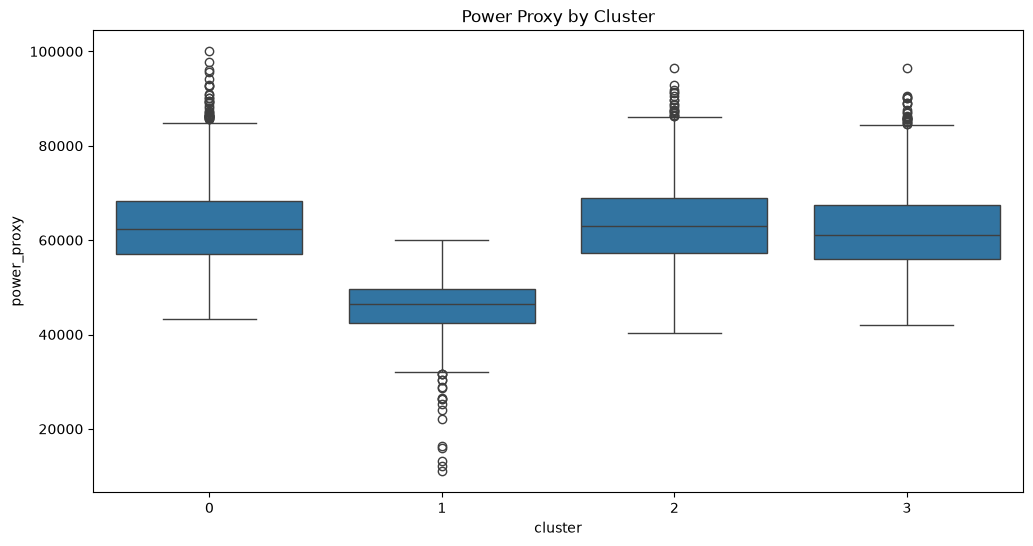

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


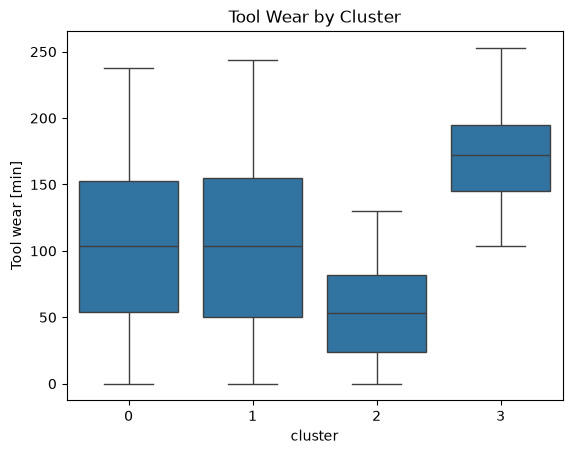

In [7]:
# Cluster Centroids Interpretation
centroids = pd.DataFrame(
    kmeans_model.cluster_centers_,
    columns=pipeline.named_steps['preprocessor'].get_feature_names_out()
)
print("Scaled Cluster Centroids:")
display(centroids.round(3))

# Visualize key features by cluster
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_analysis, x='cluster', y='power_proxy')
plt.title("Power Proxy by Cluster")
plt.show()

sns.boxplot(data=df_analysis, x='cluster', y='Tool wear [min]')
plt.title("Tool Wear by Cluster")
plt.show()

## SHAP-like Explainability for K-Means (using centroids or surrogate):


In [9]:
# Simple feature importance via centroid deviation
import numpy as np
overall_mean = X.mean(axis=0)
importance = np.abs(centroids - overall_mean).mean(axis=0)
feature_importance = pd.Series(importance, index=pipeline.named_steps['preprocessor'].get_feature_names_out())
print("Top driving features:")
print(feature_importance.sort_values(ascending=False).head(8))

Top driving features:
num__Process temperature [K]    1.052776
num__Air temperature [K]        0.911168
num__Rotational speed [rpm]     0.478786
num__Tool wear [min]            0.035320
cat__Type_L                     0.031598
num__Torque [Nm]                0.007671
cat__Type_M                     0.002383
dtype: float64


## Limitations
### Key Limitations of This Unsupervised Approach:

* No direct optimization against a business metric (e.g., failure prediction) during training — relies on post-hoc validation.
* Sensitive to scaling choices, feature engineering, and hyper-parameters (especially DBSCAN eps).
* Clusters may be unstable with new data distributions (concept drift in real factories).
* High-dimensional telemetry can still suffer from curse of dimensionality even after PCA.
* Cannot distinguish rare but critical failures if they don't form dense clusters.
* Requires domain expert interpretation of clusters.

**Mitigation in Production**: Combine with supervised models on labeled data when available, use online clustering for drift detection, and implement human-in-the-loop review.

## Bias & Fairness Audit

**Focus**: Product quality variant (Type: L, M, H) is a sensitive attribute (low-quality machines may be cheaper and more prone to issues).

**Bias Audit Code**

In [10]:
# Cluster distribution by machine Type
type_cluster = pd.crosstab(df_analysis['Type'], df_analysis['cluster'], normalize='index')
print("Proportion of each Type in Clusters:")
display(type_cluster.round(3))

# Failure rate vs cluster vs Type
bias_summary = df_analysis.groupby(['Type', 'cluster'])['Machine failure'].agg(['mean', 'count'])
print("\nFailure Rate by Type & Cluster:")
display(bias_summary)

# Disparate Impact Analysis (example: proportion in "high-risk" cluster)
high_risk_clusters = [cluster for cluster, rate in failure_rate.items() if rate > failure_rate.mean() * 1.5]
print(f"\nHigh-risk clusters: {high_risk_clusters}")

for t in ['L', 'M', 'H']:
    prop_high_risk = (df_analysis[df_analysis['Type'] == t]['cluster']
                     .isin(high_risk_clusters).mean())
    print(f"Type {t} in high-risk clusters: {prop_high_risk:.1%}")

Proportion of each Type in Clusters:


cluster,0,1,2,3
Type,,,,
H,0.396,0.165,0.216,0.223
L,0.349,0.175,0.234,0.242
M,0.351,0.169,0.250,0.230



Failure Rate by Type & Cluster:


mean  count
Type cluster                 
H    0        0.010076    397
     1        0.006061    165
     2        0.027650    217
     3        0.044643    224
L    0        0.024379   2092
     1        0.024738   1051
     2        0.042023   1404
     3        0.068135   1453
M    0        0.016144   1053
     1        0.027668    506
     2        0.033422    748
     3        0.039130    690


High-risk clusters: [3]
Type L in high-risk clusters: 24.2%
Type M in high-risk clusters: 23.0%
Type H in high-risk clusters: 22.3%
